In [30]:
"Importações necessárias"

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

In [31]:
"Carregar os dados"

movies = pd.read_csv('../data/ml-25m/movies.csv')
ratings = pd.read_csv('../data/ml-25m/ratings.csv')

print(f"Filmes: {movies.shape}")
print(f"Avaliações: {ratings.shape}")



Filmes: (62423, 3)
Avaliações: (25000095, 4)


In [35]:
"Visualizar filmes"

movies.head(10)

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy
5,6,Heat (1995),Action|Crime|Thriller
6,7,Sabrina (1995),Comedy|Romance
7,8,Tom and Huck (1995),Adventure|Children
8,9,Sudden Death (1995),Action
9,10,GoldenEye (1995),Action|Adventure|Thriller


In [36]:
"Visualizar avaliações"

ratings.head(10)

,userId,movieId,rating,timestamp
0,1,296,5.0,1147880044
1,1,306,3.5,1147868817
2,1,307,5.0,1147868828
3,1,665,5.0,1147878820
4,1,899,3.5,1147868510
5,1,1088,4.0,1147868495
6,1,1175,3.5,1147868826
7,1,1217,3.5,1147878326
8,1,1237,5.0,1147868839
9,1,1250,4.0,1147868414


In [37]:
"Estatísticas Gerais:"

print("=== RATINGS ===")
print(f"Total de avaliações: {len(ratings):,}")
print(f"Total de usuários únicos: {ratings['userId'].nunique():,}")
print(f"Total de filmes avaliados: {ratings['movieId'].nunique():,}")
print(f"\nNota mínima: {ratings['rating'].min()}")
print(f"Nota máxima: {ratings['rating'].max()}")
print(f"Nota média: {ratings['rating'].mean():.2f}")

=== RATINGS ===
Total de avaliações: 25,000,095
Total de usuários únicos: 162,541
Total de filmes avaliados: 59,047

Nota mínima: 0.5
Nota máxima: 5.0
Nota média: 3.53


In [39]:
"Filmes mais avaliados:"

top_filmes = (ratings.groupby('movieId')['rating']
              .count()
              .reset_index()
              .rename(columns={'rating': 'total_avaliacoes'})
              .merge(movies[['movieId', 'title']], on='movieId')
              .sort_values('total_avaliacoes', ascending=False)
              .head(10))

top_filmes[['title', 'total_avaliacoes']]

,title,total_avaliacoes
351,Forrest Gump (1994),81491
314,"Shawshank Redemption, The (1994)",81482
292,Pulp Fiction (1994),79672
585,"Silence of the Lambs, The (1991)",74127
2480,"Matrix, The (1999)",72674
257,Star Wars: Episode IV - A New Hope (1977),68717
475,Jurassic Park (1993),64144
522,Schindler's List (1993),60411
108,Braveheart (1995),59184
2867,Fight Club (1999),58773


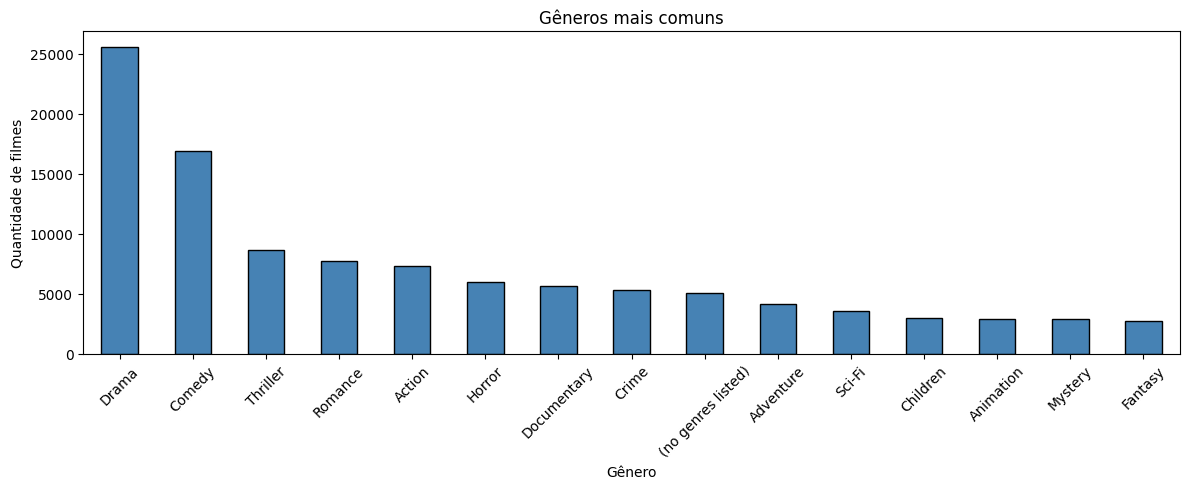

In [40]:
"Gêneros mais comuns:"

generos = movies['genres'].str.split('|').explode()
generos_count = generos.value_counts().head(15)

plt.figure(figsize=(12, 5))
generos_count.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Gêneros mais comuns')
plt.xlabel('Gênero')
plt.ylabel('Quantidade de filmes')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Média de avaliações por usuário: 154
Mediana de avaliações por usuário: 71
Usuário mais ativo: 32,202 avaliações


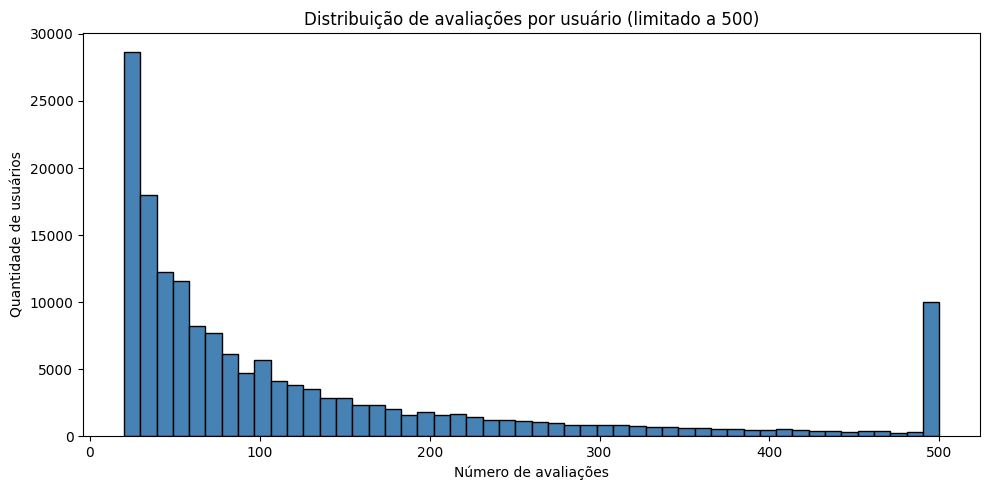

In [41]:
"Usuários mais ativos:"

avaliacoes_por_usuario = ratings.groupby('userId')['rating'].count()

print(f"Média de avaliações por usuário: {avaliacoes_por_usuario.mean():.0f}")
print(f"Mediana de avaliações por usuário: {avaliacoes_por_usuario.median():.0f}")
print(f"Usuário mais ativo: {avaliacoes_por_usuario.max():,} avaliações")

plt.figure(figsize=(10, 5))
avaliacoes_por_usuario.clip(upper=500).plot(kind='hist', bins=50, color='steelblue', edgecolor='black')
plt.title('Distribuição de avaliações por usuário (limitado a 500)')
plt.xlabel('Número de avaliações')
plt.ylabel('Quantidade de usuários')
plt.tight_layout()
plt.show()

In [42]:
"Filtro de usuários e filmes:"

# Manter apenas usuários com pelo menos 20 avaliações
# e filmes com pelo menos 50 avaliações
min_avaliacoes_usuario = 20
min_avaliacoes_filme = 50

usuarios_ativos = ratings.groupby('userId').filter(
    lambda x: len(x) >= min_avaliacoes_usuario
)

filmes_populares = usuarios_ativos.groupby('movieId').filter(
    lambda x: len(x) >= min_avaliacoes_filme
)

print(f"Avaliações após filtro: {len(filmes_populares):,}")
print(f"Usuários únicos: {filmes_populares['userId'].nunique():,}")
print(f"Filmes únicos: {filmes_populares['movieId'].nunique():,}")

Avaliações após filtro: 24,644,928
Usuários únicos: 162,540
Filmes únicos: 13,176


In [43]:
"Amostra para Desenvolvimento:"

# Usamos 20% dos usuários para treinar rapidamente
# Em produção usaríamos tudo
np.random.seed(42)
usuarios_sample = np.random.choice(
    filmes_populares['userId'].unique(),
    size=int(filmes_populares['userId'].nunique() * 0.2),
    replace=False
)

df_sample = filmes_populares[filmes_populares['userId'].isin(usuarios_sample)].copy()

print(f"Amostra final: {len(df_sample):,} avaliações")
print(f"Usuários: {df_sample['userId'].nunique():,}")
print(f"Filmes: {df_sample['movieId'].nunique():,}")

# Salvar para usar no modelo
df_sample.to_csv('../data/ratings_sample.csv', index=False)
print("\n✅ Amostra salva em data/ratings_sample.csv")

Amostra final: 4,894,403 avaliações
Usuários: 32,508
Filmes: 13,176

✅ Amostra salva em data/ratings_sample.csv


In [49]:
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics.pairwise import cosine_similarity
import pickle, os
import numpy as np

print("⏳ Construindo matriz usuário-filme...")

# Criar matriz usuário-filme (amostra menor para ser rápido)
df_pivot = df_sample.pivot_table(
    index='userId', 
    columns='movieId', 
    values='rating',
    fill_value=0
)

print(f"Matriz: {df_pivot.shape}")

# Treinar SVD
print("⏳ Treinando SVD...")
svd = TruncatedSVD(n_components=50, random_state=42)
matriz_reduzida = svd.fit_transform(df_pivot)

print(f"✅ SVD treinado!")
print(f"Variância explicada: {svd.explained_variance_ratio_.sum():.2%}")

# Salvar modelo e dados
os.makedirs('../data/models', exist_ok=True)
with open('../data/models/svd_model.pkl', 'wb') as f:
    pickle.dump({
        'svd': svd,
        'matriz_reduzida': matriz_reduzida,
        'df_pivot': df_pivot,
        'user_ids': df_pivot.index.tolist(),
        'movie_ids': df_pivot.columns.tolist()
    }, f)

print("✅ Modelo salvo em data/models/svd_model.pkl")

⏳ Construindo matriz usuário-filme...
Matriz: (32508, 13176)
⏳ Treinando SVD...
✅ SVD treinado!
Variância explicada: 36.55%
✅ Modelo salvo em data/models/svd_model.pkl


In [50]:
"Recomendar filmes:"

def recomendar_filmes(user_id, df_pivot, matriz_reduzida, movies_df, n=10):
    # Verificar se usuário existe
    if user_id not in df_pivot.index:
        print(f"Usuário {user_id} não encontrado na amostra.")
        return None
    
    # Índice do usuário na matriz
    user_idx = df_pivot.index.get_loc(user_id)
    
    # Similaridade do usuário com todos os outros
    user_vec = matriz_reduzida[user_idx].reshape(1, -1)
    similaridades = cosine_similarity(user_vec, matriz_reduzida)[0]
    
    # Top 20 usuários mais similares (excluindo ele mesmo)
    usuarios_similares = np.argsort(similaridades)[::-1][1:21]
    
    # Filmes que o usuário já viu
    filmes_vistos = set(df_pivot.columns[df_pivot.loc[user_id] > 0])
    
    # Pontuação dos filmes baseada nos usuários similares
    pontuacoes = {}
    for idx in usuarios_similares:
        similar_user_id = df_pivot.index[idx]
        peso = similaridades[idx]
        filmes_usuario = df_pivot.loc[similar_user_id]
        
        for movie_id, rating in filmes_usuario.items():
            if rating > 0 and movie_id not in filmes_vistos:
                if movie_id not in pontuacoes:
                    pontuacoes[movie_id] = 0
                pontuacoes[movie_id] += rating * peso
    
    # Top N filmes
    top_filmes = sorted(pontuacoes.items(), key=lambda x: x[1], reverse=True)[:n]
    
    # Montar resultado com títulos
    resultado = []
    for movie_id, score in top_filmes:
        titulo = movies_df[movies_df['movieId'] == movie_id]['title'].values
        genero = movies_df[movies_df['movieId'] == movie_id]['genres'].values
        if len(titulo) > 0:
            resultado.append({
                'movieId': movie_id,
                'title': titulo[0],
                'genres': genero[0],
                'score': round(score, 3)
            })
    
    return pd.DataFrame(resultado)

# Testar com um usuário real
usuario_teste = df_sample['userId'].iloc[100]

print(f"🎬 Filmes já avaliados pelo usuário {usuario_teste}:")
filmes_avaliados = (df_sample[df_sample['userId'] == usuario_teste]
                    .merge(movies, on='movieId')[['title', 'rating']]
                    .sort_values('rating', ascending=False)
                    .head(5))
print(filmes_avaliados.to_string(index=False))

print(f"\n🎯 Top 10 recomendações para o usuário {usuario_teste}:\n")
recomendacoes = recomendar_filmes(usuario_teste, df_pivot, matriz_reduzida, movies)
print(recomendacoes.to_string(index=False))

🎬 Filmes já avaliados pelo usuário 5:
                                    title  rating
Twelve Monkeys (a.k.a. 12 Monkeys) (1995)     5.0
                  Dead Man Walking (1995)     5.0
                     Birdcage, The (1996)     5.0
               Usual Suspects, The (1995)     5.0
              Seven (a.k.a. Se7en) (1995)     5.0

🎯 Top 10 recomendações para o usuário 5:

 movieId                                                                          title                            genres  score
     318                                               Shawshank Redemption, The (1994)                       Crime|Drama 61.683
     110                                                              Braveheart (1995)                  Action|Drama|War 59.211
     805                                                         Time to Kill, A (1996)                    Drama|Thriller 56.780
     480                                                           Jurassic Park (1993)  Action|Adventu